# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

pd.set_option('display.max_columns', 100)

# 1. Data Collection

load data and inspect structure to verify dimensions and column types

In [3]:
df = pd.read_csv('data.csv')

# Rename the unnamed index-like column to keep references explicit.
first_col = df.columns[0]
if str(first_col).startswith('Unnamed') or first_col == '':
    df = df.rename(columns={first_col: 'row_id'})

print('Shape:', df.shape)
print('Columns:')
print(df.columns.tolist())
df.head()

Shape: (1697, 32)
Columns:
['row_id', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'lastfm_url', 'track', 'artist', 'seeds', 'number_of_emotion_tags', 'valence_tags', 'arousal_tags', 'dominance_tags', 'mbid', 'spotify_id', 'genre']


,row_id,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
0,0,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,-8.822,1,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3,acoustic,https://www.last.fm/music/a%2bgreat%2bbig%2bwo...,Say Something,A Great Big World,['sad'],7,2.887157,3.535294,4.034216,4a88e54b-3fd9-4d99-9787-ea2853cfbba1,6Vc5wAMmXdKIAM7WUoEb7N,indie pop
1,1,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.414,0,-8.700,1,0.0369,0.294,0.000000,0.1510,0.6690,130.088,4,acoustic,https://www.last.fm/music/jason%2bmraz/_/lucky,Lucky,Jason Mraz,"['romantic', 'sweet']",10,7.779724,4.980663,6.143867,f68a7497-91aa-4d8a-88c8-abc0ba5b49f7,0IktbUcnAGrvD03AWnz3Q8,acoustic
2,2,1KHdq8NK9QxnGjdXb55NiG,Landon Pigg,The Boy Who Never,Falling in Love at a Coffee Shop,58,244986,False,0.489,0.561,4,-7.933,1,0.0274,0.200,0.000046,0.1790,0.2380,83.457,3,acoustic,https://www.last.fm/music/landon%2bpigg/_/fall...,Falling In Love At A Coffee Shop,Landon Pigg,"['soothing', 'romantic', 'sweet', 'calm']",20,7.004538,3.695087,6.201908,614a39e0-ebe9-453c-8dc4-e004676c345b,1KHdq8NK9QxnGjdXb55NiG,acoustic
3,3,1KHdq8NK9QxnGjdXb55NiG,Landon Pigg,The Boy Who Never,Falling in Love at a Coffee Shop,58,244986,False,0.489,0.561,4,-7.933,1,0.0274,0.200,0.000046,0.1790,0.2380,83.457,3,acoustic,https://www.last.fm/music/landon%2bpigg/_/coff...,Coffee Shop,Landon Pigg,['thoughtful'],4,7.364104,4.021567,6.479030,NaN,1KHdq8NK9QxnGjdXb55NiG,indie
4,4,5JDcQAztvZTIkrWoZihgvC,Ron Pope,The Bedroom Demos,A Drop in the Ocean,68,220239,False,0.447,0.393,5,-8.650,1,0.0380,0.785,0.000000,0.2800,0.5640,73.139,3,acoustic,https://www.last.fm/music/ron%2bpope/_/a%2bdro...,A Drop In The Ocean,Ron Pope,['romantic'],14,7.275094,4.950283,5.977500,9b347a38-772d-4019-b5ff-eeacd31109e3,5JDcQAztvZTIkrWoZihgvC,piano


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   row_id                  1697 non-null   int64  
 1   track_id                1697 non-null   str    
 2   artists                 1697 non-null   str    
 3   album_name              1697 non-null   str    
 4   track_name              1697 non-null   str    
 5   popularity              1697 non-null   int64  
 6   duration_ms             1697 non-null   int64  
 7   explicit                1697 non-null   bool   
 8   danceability            1697 non-null   float64
 9   energy                  1697 non-null   float64
 10  key                     1697 non-null   int64  
 11  loudness                1697 non-null   float64
 12  mode                    1697 non-null   int64  
 13  speechiness             1697 non-null   float64
 14  acousticness            1697 non-null   float64
 15

# 2. Cleaning

check missing values and remove duplicates to ensure data integrity

In [5]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame('missing_count')
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .sort_values('missing_count', ascending=False)
)

missing_summary.head(15)

,missing_count,missing_pct
mbid,325,19.15
row_id,0,0.00
artists,0,0.00
track_id,0,0.00
track_name,0,0.00
popularity,0,0.00
duration_ms,0,0.00
album_name,0,0.00
danceability,0,0.00
energy,0,0.00


Note: `mbid` is the only field with missing values, which likely reflects metadata coverage rather than a data-entry error. In practice, this suggests some tracks are not matched to a Last.fm MusicBrainz identifier (for example, newer releases, niche tracks, or alternate versions). Because `spotify_id` is present and used as the main unique key, rows with missing `mbid` can be kept for Spotify-based analysis. 

### Duplicate ID Relationship Check
This check uses the raw dataset (before cleaning) to answer three questions:
1. How much overlap exists between duplicate `spotify_id` rows and duplicate `mbid` rows?
2. Why can duplicate counts differ across the two IDs?
3. How can `mbid` be both often missing and also highly duplicated?

In [23]:
# Rebuild a pre-clean view for duplicate diagnostics.
df_raw = pd.read_csv('data.csv')
first_col_raw = df_raw.columns[0]
if str(first_col_raw).startswith('Unnamed') or first_col_raw == '':
    df_raw = df_raw.rename(columns={first_col_raw: 'row_id'})

# Row-level duplicate flags (excluding NaN in key columns).
spotify_dup_mask = df_raw['spotify_id'].notna() & df_raw.duplicated(subset=['spotify_id'], keep=False)
mbid_dup_mask = df_raw['mbid'].notna() & df_raw.duplicated(subset=['mbid'], keep=False)
mbid_missing_mask = df_raw['mbid'].isna()

n_rows = len(df_raw)
n_spotify_dup_rows = int(spotify_dup_mask.sum())
n_mbid_dup_rows = int(mbid_dup_mask.sum())
n_overlap_rows = int((spotify_dup_mask & mbid_dup_mask).sum())
n_spotify_only_dup_rows = int((spotify_dup_mask & ~mbid_dup_mask).sum())
n_mbid_only_dup_rows = int((mbid_dup_mask & ~spotify_dup_mask).sum())
n_mbid_missing = int(mbid_missing_mask.sum())

print('Raw rows:', n_rows)
print('Rows with duplicated spotify_id:', n_spotify_dup_rows)
print('Rows with duplicated mbid (non-missing):', n_mbid_dup_rows)
print('Rows duplicated in BOTH spotify_id and mbid:', n_overlap_rows)
print('Rows duplicated ONLY in spotify_id:', n_spotify_only_dup_rows)
print('Rows duplicated ONLY in mbid:', n_mbid_only_dup_rows)
print('Rows with missing mbid:', n_mbid_missing)

if n_spotify_dup_rows > 0:
    print('Share of spotify-duplicate rows also duplicated on mbid:', round(n_overlap_rows / n_spotify_dup_rows, 3))
if n_mbid_dup_rows > 0:
    print('Share of mbid-duplicate rows also duplicated on spotify_id:', round(n_overlap_rows / n_mbid_dup_rows, 3))

# Compare cardinality among non-missing rows.
non_missing_mbid = df_raw[df_raw['mbid'].notna()]
print('\nUnique counts among non-missing mbid rows:')
print('Unique spotify_id:', non_missing_mbid['spotify_id'].nunique())
print('Unique mbid:', non_missing_mbid['mbid'].nunique())

print('- Different duplicate counts are expected because spotify_id and mbid represent different systems.')
print('- A single mbid can map to multiple Spotify entries (regional versions, reuploads, alternate releases).')
print('- Missing mbid rows are excluded from mbid duplicate checks, so missingness and duplication can both be high.')

Raw rows: 1697
Rows with duplicated spotify_id: 848
Rows with duplicated mbid (non-missing): 638
Rows duplicated in BOTH spotify_id and mbid: 638
Rows duplicated ONLY in spotify_id: 210
Rows duplicated ONLY in mbid: 0
Rows with missing mbid: 325
Share of spotify-duplicate rows also duplicated on mbid: 0.752
Share of mbid-duplicate rows also duplicated on spotify_id: 1.0

Unique counts among non-missing mbid rows:
Unique spotify_id: 992
Unique mbid: 1012
- Different duplicate counts are expected because spotify_id and mbid represent different systems.
- A single mbid can map to multiple Spotify entries (regional versions, reuploads, alternate releases).
- Missing mbid rows are excluded from mbid duplicate checks, so missingness and duplication can both be high.


In [25]:
# Re-clean dataset based on duplicate-ID diagnostics.
# Rule: keep one row per spotify_id; prefer rows with non-missing mbid.

if 'df_raw' not in globals():
    df_raw = pd.read_csv('data.csv')
    first_col_raw = df_raw.columns[0]
    if str(first_col_raw).startswith('Unnamed') or first_col_raw == '':
        df_raw = df_raw.rename(columns={first_col_raw: 'row_id'})

df = df_raw.copy()

# Prefer non-missing mbid rows when duplicate spotify_id exists.
df['_mbid_missing'] = df['mbid'].isna().astype(int)

# Prefer richer metadata as a tiebreaker among same spotify_id.
if 'number_of_emotion_tags' in df.columns:
    df['_tags_score'] = pd.to_numeric(df['number_of_emotion_tags'], errors='coerce').fillna(-1)
else:
    df['_tags_score'] = -1

df = (
    df.sort_values(['spotify_id', '_mbid_missing', '_tags_score'], ascending=[True, True, False])
      .drop_duplicates(subset=['spotify_id'], keep='first')
      .drop_duplicates()
      .reset_index(drop=True)
)

df = df.drop(columns=['_mbid_missing', '_tags_score'])

print('After ID-aware re-cleaning')
print('Rows:', len(df))
print('Exact duplicate rows:', int(df.duplicated().sum()))
print('Duplicate spotify_id:', int(df.duplicated(subset=['spotify_id']).sum()))
print('Duplicate mbid (non-missing):', int(df[df['mbid'].notna()].duplicated(subset=['mbid']).sum()))
print('Missing mbid rows kept:', int(df['mbid'].isna().sum()))
print('Remaining missing values (all columns):', int(df.isna().sum().sum()))

After ID-aware re-cleaning
Rows: 1202
Exact duplicate rows: 0
Duplicate spotify_id: 0
Duplicate mbid (non-missing): 0
Missing mbid rows kept: 210
Remaining missing values (all columns): 210


Note here: Use `spotify_id` as the primary unique key and keep rows with missing `mbid`.
This avoids over-dropping data while still removing duplicated track records.

# 3. Summarisation

Summarize by feature type, not with one table for everything:

1. Numeric columns first: they drive scale, spread, skew, and outlier checks (`mean`, `std`, quantiles).
2. Boolean/binary columns next (`explicit`, `mode`): use counts and proportions.
3. Categorical columns next (`track_genre`, `genre`, `artist`, `key`, `time_signature`): use frequency tables and concentration (top categories).
4. Identifier/text/link columns (`spotify_id`, `mbid`, `track_id`, `lastfm_url`, names/tags fields): do not use numeric summary; only check uniqueness, duplicates, and missingness.

In [7]:
numeric_cols = [
    'popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'number_of_emotion_tags',
    'arousal_tags', 'valence_tags', 'dominance_tags'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,978.0,51.991820,19.173931,5.000000,4.200000e+01,56.000000,66.000000,92.000
duration_ms,978.0,256394.360941,118028.374039,37626.000000,1.927865e+05,232746.500000,290993.250000,1412451.000
danceability,978.0,0.502639,0.163761,0.000000,3.812500e-01,0.512000,0.625000,0.951
energy,978.0,0.588139,0.256234,0.000020,3.922500e-01,0.601500,0.803750,0.995
loudness,978.0,-9.378983,5.128291,-37.264000,-1.143700e+01,-8.468000,-5.836250,-1.452
speechiness,978.0,0.058212,0.057652,0.000000,3.112500e-02,0.038500,0.057975,0.556
acousticness,978.0,0.299583,0.329109,0.000001,1.200000e-02,0.157500,0.561000,0.996
instrumentalness,978.0,0.178734,0.317963,0.000000,2.575000e-07,0.000535,0.176000,0.988
liveness,978.0,0.193255,0.163735,0.023500,9.725000e-02,0.124000,0.240750,0.965
valence,978.0,0.428508,0.253152,0.000000,2.110000e-01,0.393500,0.623250,0.978


In [ ]:
# boolean/categorical/id summaries.
bool_cols = ['explicit', 'mode']
cat_cols_summary = ['track_genre', 'genre', 'artist', 'key', 'time_signature']
id_cols = ['spotify_id', 'mbid', 'track_id']

print('Boolean / binary columns (count and share):')
for col in bool_cols:
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    print(f"\n{col}")
    print(pd.DataFrame({'count': counts, 'pct': pct}))

print('\nTop categories (first 10):')
for col in cat_cols_summary:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))

print('\nID quality check:')
for col in id_cols:
    print(f"{col}: unique={df[col].nunique()}, missing={int(df[col].isna().sum())}, duplicated={int(df[col].duplicated().sum())}")

Boolean / binary columns (count and share):

explicit
          count    pct
explicit              
False      1103  91.76
True         99   8.24

mode
      count    pct
mode              
1       796  66.22
0       406  33.78

Top categories (first 10):

track_genre
track_genre
british       96
psych-rock    61
acoustic      55
trip-hop      53
grunge        49
new-age       47
power-pop     43
piano         36
industrial    33
idm           30
Name: count, dtype: int64

genre
genre
pop             124
rock            113
classic rock     96
electronic       62
indie            52
soundtrack       41
ambient          33
soul             32
alternative      30
trip-hop         27
Name: count, dtype: int64

artist
artist
The Beatles               55
Pink Floyd                17
John Mayer                14
The Red Chord             10
Elvis Presley              9
Glee Cast                  9
Enigma                     8
Air                        7
The Smiths                 7
The Velv

Can use above for talking about limitation -> that the analysis/models might be weak for xyz genre.

In [27]:
# Complete summarization analysis with concise, report-ready outputs.

if 'numeric_cols' not in globals():
    numeric_cols = [
        'popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
        'valence', 'tempo', 'number_of_emotion_tags',
        'arousal_tags', 'valence_tags', 'dominance_tags'
    ]

if 'bool_cols' not in globals():
    bool_cols = ['explicit', 'mode']
if 'cat_cols_summary' not in globals():
    cat_cols_summary = ['track_genre', 'genre', 'artist', 'key', 'time_signature']
if 'id_cols' not in globals():
    id_cols = ['spotify_id', 'mbid', 'track_id']

# 1) Numeric summary with skewness and IQR outlier rate.
num_stats = df[numeric_cols].describe().T
num_stats['skew'] = df[numeric_cols].skew(numeric_only=True)

iqr_rows = []
for col in numeric_cols:
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    pct = ((s < low) | (s > high)).mean() * 100
    iqr_rows.append({'feature': col, 'outlier_pct_iqr': round(float(pct), 2)})

outlier_rates = pd.DataFrame(iqr_rows).set_index('feature')
num_summary = num_stats.join(outlier_rates)

print('Numeric summary (top skew / outlier columns):')
print(num_summary[['mean', 'std', 'skew', 'outlier_pct_iqr']].sort_values('outlier_pct_iqr', ascending=False).head(8))

# 2) Boolean summary.
bool_rows = []
for col in bool_cols:
    counts = df[col].value_counts(dropna=False)
    total = len(df)
    top_value = counts.index[0]
    top_count = int(counts.iloc[0])
    bool_rows.append({
        'feature': col,
        'top_value': top_value,
        'top_count': top_count,
        'top_pct': round(top_count / total * 100, 2)
    })

bool_summary = pd.DataFrame(bool_rows)
print('\nBoolean dominance summary:')
print(bool_summary)

# 3) Categorical concentration summary.
cat_rows = []
for col in cat_cols_summary:
    vc = df[col].value_counts(dropna=False)
    total = len(df)
    cat_rows.append({
        'feature': col,
        'n_unique': int(df[col].nunique(dropna=True)),
        'top_category': vc.index[0],
        'top_count': int(vc.iloc[0]),
        'top_pct': round(vc.iloc[0] / total * 100, 2)
    })

cat_summary = pd.DataFrame(cat_rows).sort_values('top_pct', ascending=False)
print('\nCategorical concentration summary:')
print(cat_summary)

# 4) ID quality summary.
id_rows = []
for col in id_cols:
    id_rows.append({
        'id_field': col,
        'unique': int(df[col].nunique(dropna=True)),
        'missing': int(df[col].isna().sum()),
        'duplicated_rows': int(df[col].duplicated().sum())
    })

id_summary = pd.DataFrame(id_rows)
print('\nID quality summary:')
print(id_summary)

# Concise findings block.
print('\nDirect findings:')
print('- Numeric: strongest IQR outlier pressure is concentrated in the top few features listed above.')
print('- Boolean: explicit and mode are imbalanced, so class proportions should be reported with any model result.')
print('- Categorical: top_pct identifies concentration risk (dominant categories can bias aggregate trends).')
print('- IDs: spotify_id and track_id are clean unique keys after re-cleaning; mbid remains partially missing by design.')

Numeric summary (top skew / outlier columns):
                           mean            std      skew  outlier_pct_iqr
instrumentalness       0.173646       0.316392  1.567367            20.05
speechiness            0.062580       0.062381  3.710465            10.98
liveness               0.191898       0.164933  2.338768             6.74
duration_ms       254422.881864  115621.971522  3.197613             5.99
loudness              -9.232613       5.137584 -1.804065             4.49
dominance_tags         5.434708       1.113680 -1.157965             3.33
arousal_tags           4.358860       1.086141 -0.318995             2.08
valence_tags           5.835089       1.545048 -0.726304             0.92

Boolean dominance summary:
    feature top_value  top_count  top_pct
0  explicit     False       1103    91.76
1      mode         1        796    66.22

Categorical concentration summary:
          feature  n_unique top_category  top_count  top_pct
4  time_signature         5          

Several predictors are strongly right-skewed, especially speechiness, duration_ms, liveness, and instrumentalness.
-> This means averages alone are not representative for these features.
Outliers are concentrated in a few variables (instrumentalness highest, then speechiness, liveness, duration_ms).
-> These variables can disproportionately influence correlation and linear-model coefficients.
Emotional tag variables (arousal_tags, valence_tags, dominance_tags) are less extreme than some audio features, so model instability is more likely to come from audio-feature tails than from label distributions.
-> Feature scales are very different (duration_ms vs bounded 0-1 features), so unscaled models are harder to interpret and can be numerically unstable.

Limitations (Genre)

The analysis is global, but feature distributions likely differ by genre.
Model performance may be weaker for underrepresented or stylistically distinct genres (for example, niche electronic subgenres, ambient, or experimental genres with atypical instrumentalness/speechiness patterns).

# 4. Visual Exploration

plot distributions for all numeric features to assess skewness, spread, and unusual tails across the full feature set

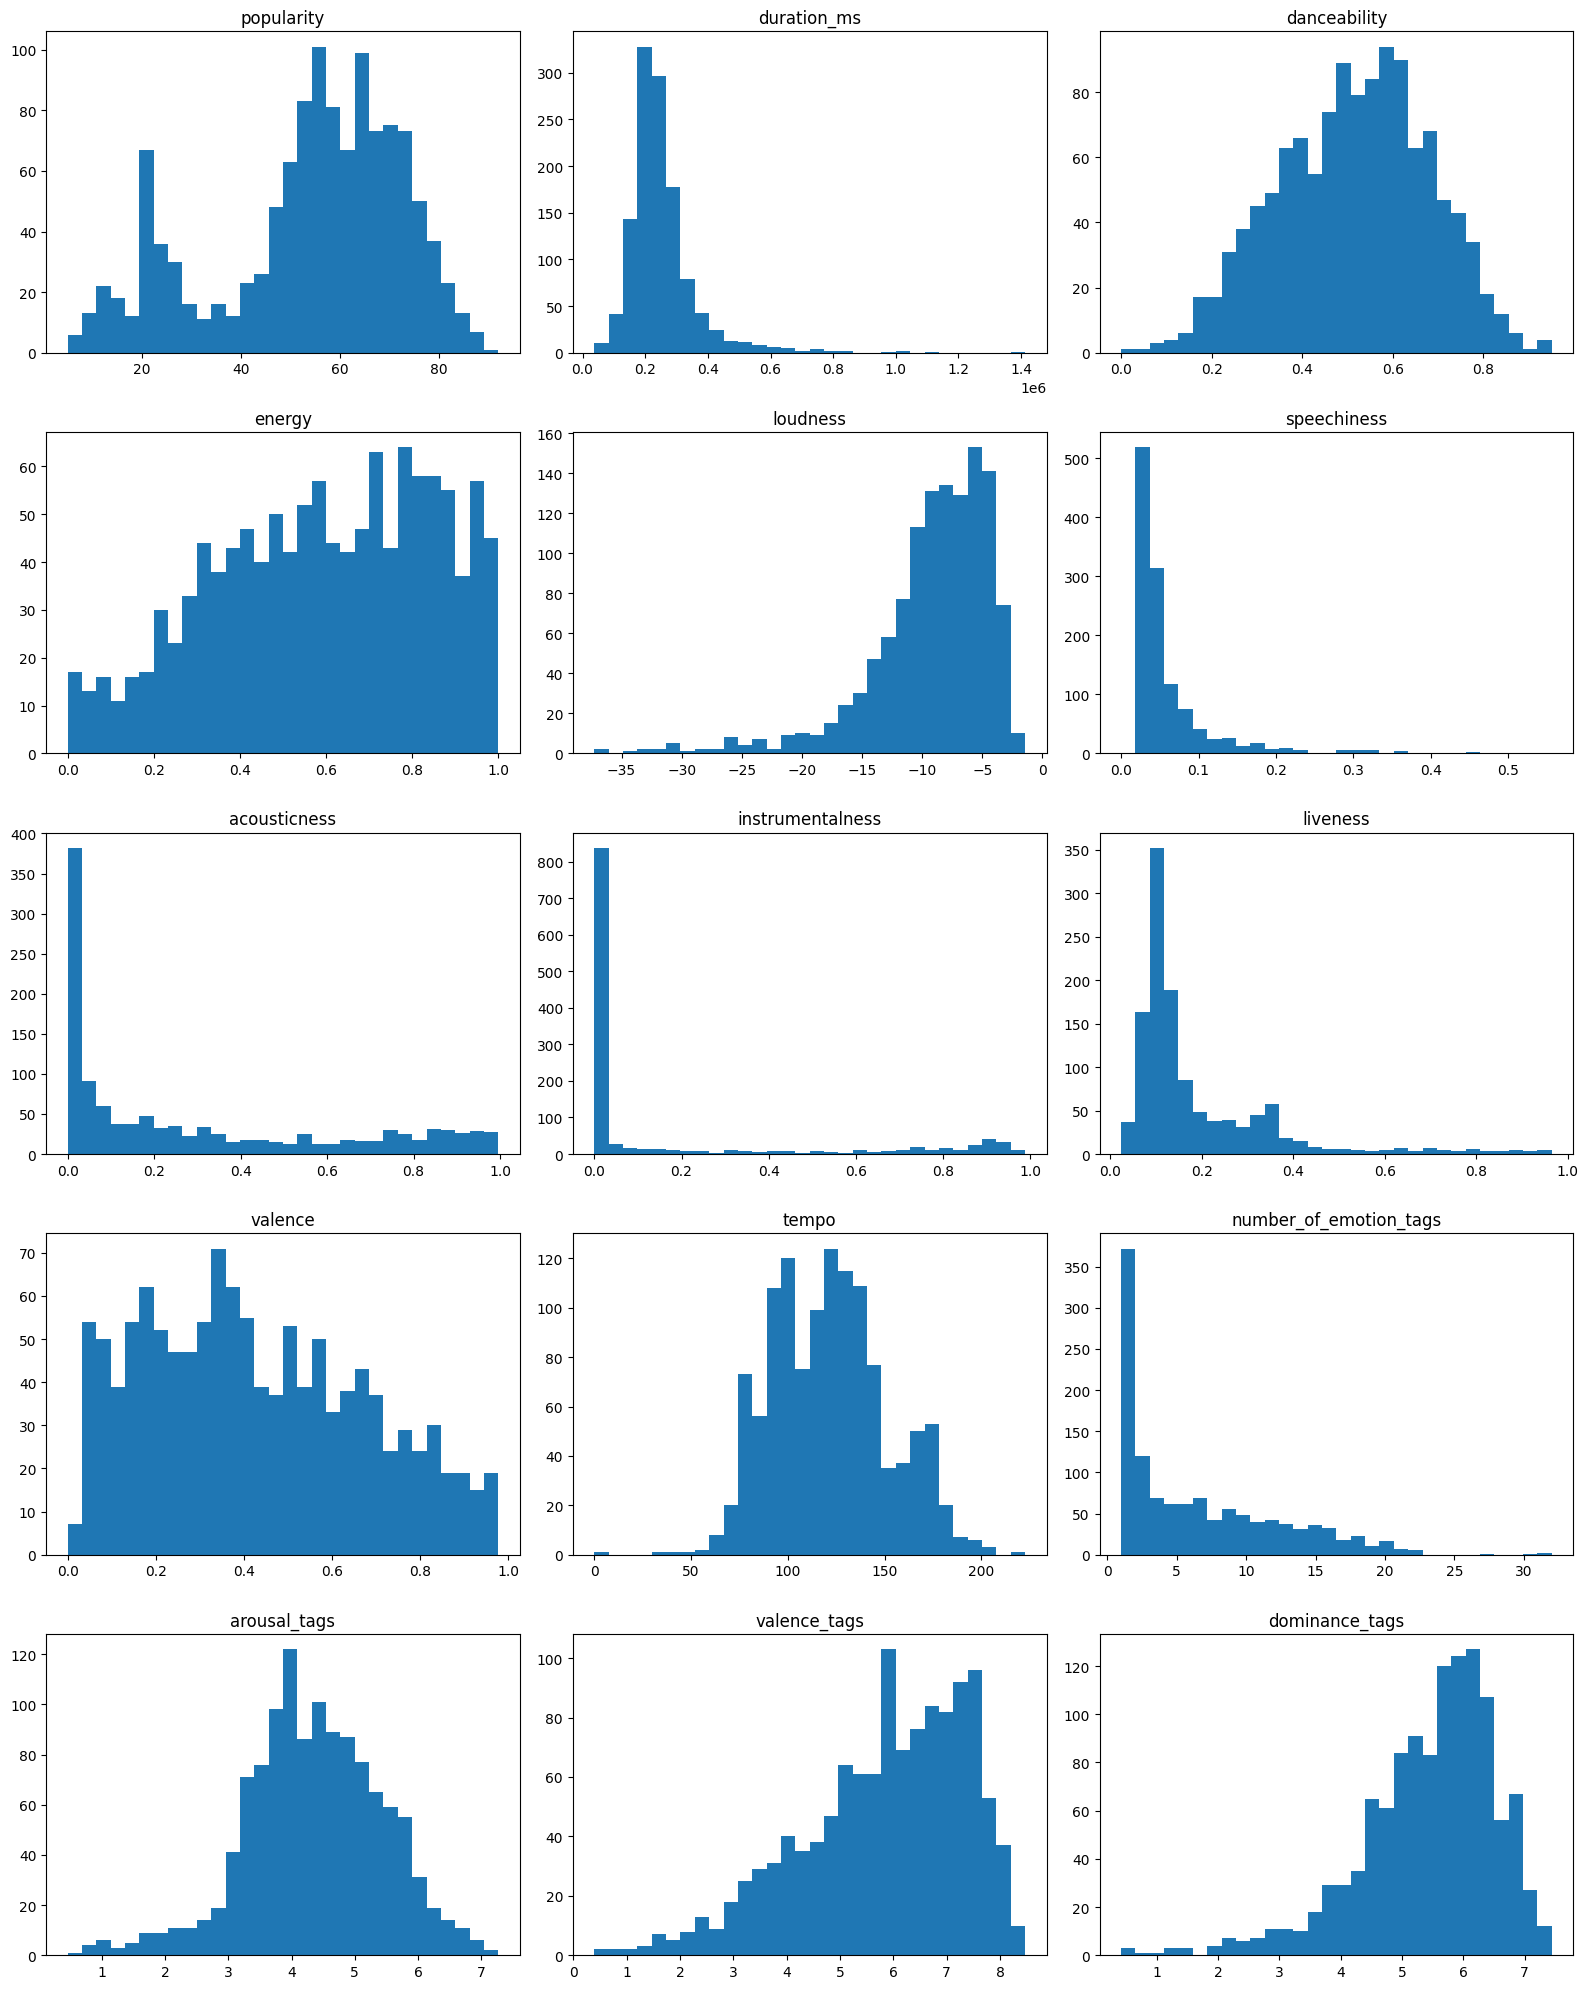

In [28]:
# Distribution plots for all numeric columns.
plot_cols = numeric_cols.copy()

n_cols = 3
n_plots = len(plot_cols)
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

plot top categories for nominal columns to check class balance

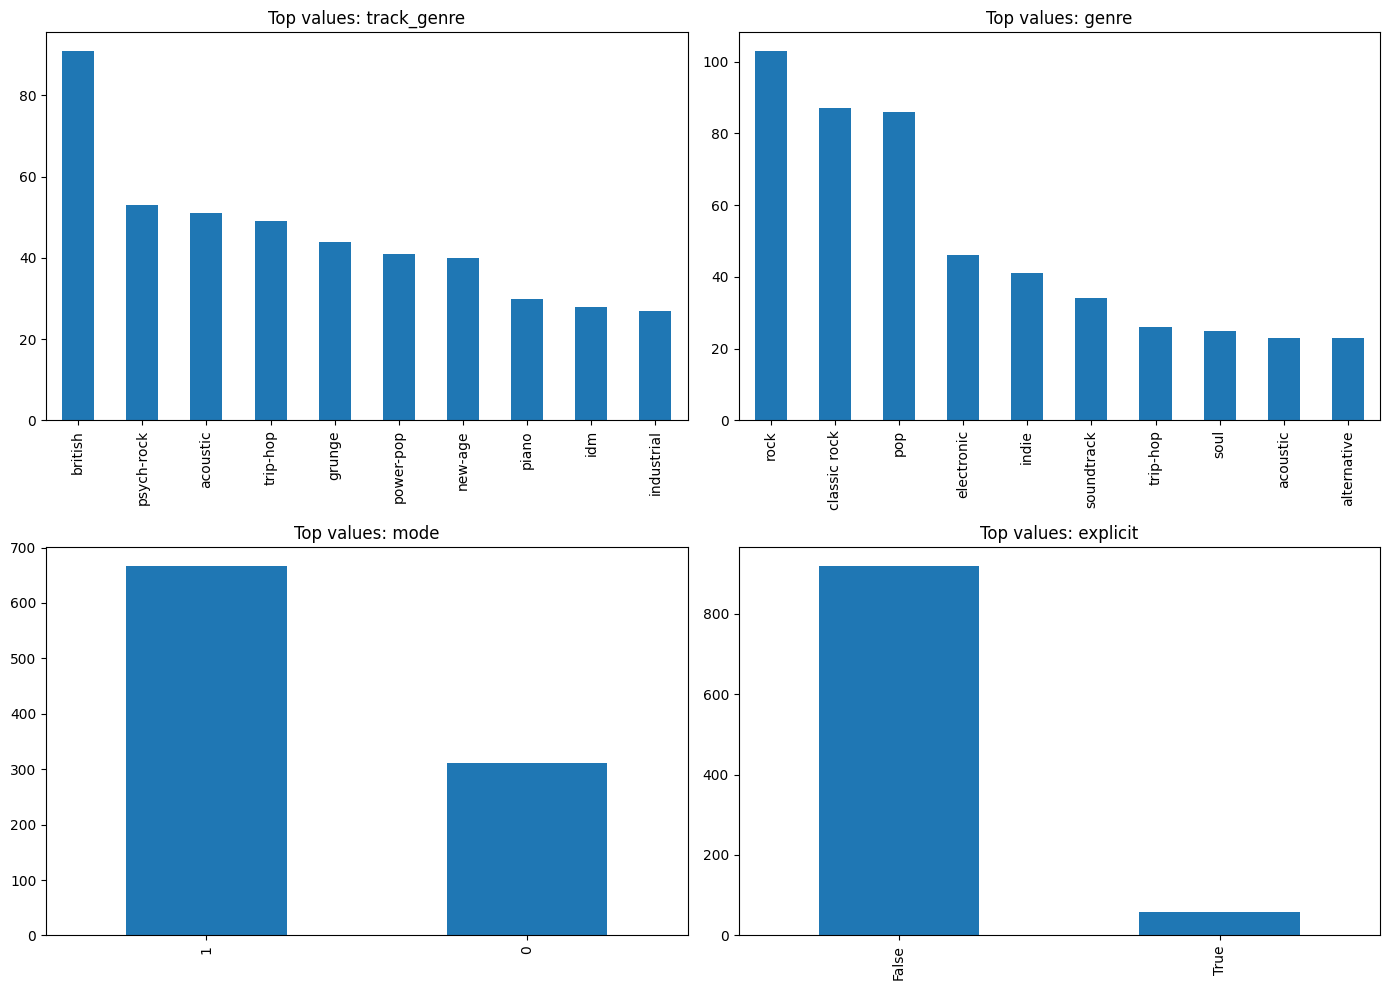

In [9]:
cat_cols = ['track_genre', 'genre', 'mode', 'explicit']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top_vals = df[col].value_counts(dropna=False).head(10)
    top_vals.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Top values: {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

calculate pairwise correlations to identify collinear subsets

In [ ]:
# Correlation scan across all numeric features.
corr_cols = numeric_cols.copy()

pair_rows = []
for feature_1, feature_2 in combinations(corr_cols, 2):
    pair_df = df[[feature_1, feature_2]].dropna()
    corr_value = pair_df[feature_1].corr(pair_df[feature_2])
    pair_rows.append({
        'feature_1': feature_1,
        'feature_2': feature_2,
        'corr': corr_value,
        'abs_corr': abs(corr_value)
    })

pair_corr = pd.DataFrame(pair_rows).sort_values('abs_corr', ascending=False).reset_index(drop=True)
pair_corr.head(15)

,feature_1,feature_2,corr,abs_corr
0,valence_tags,dominance_tags,0.883435,0.883435
1,energy,acousticness,-0.756887,0.756887
2,arousal_tags,dominance_tags,0.556594,0.556594
3,arousal_tags,valence_tags,0.537752,0.537752
4,danceability,valence,0.500283,0.500283
5,energy,valence,0.328368,0.328368
6,energy,arousal_tags,0.326970,0.326970
7,acousticness,arousal_tags,-0.248133,0.248133
8,valence,arousal_tags,0.244805,0.244805
9,valence,dominance_tags,0.233641,0.233641


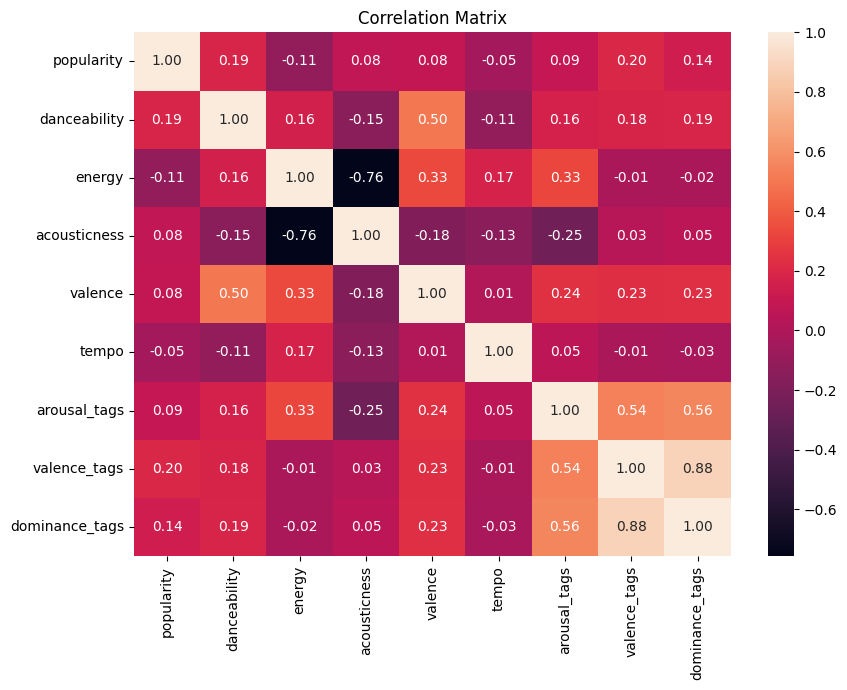

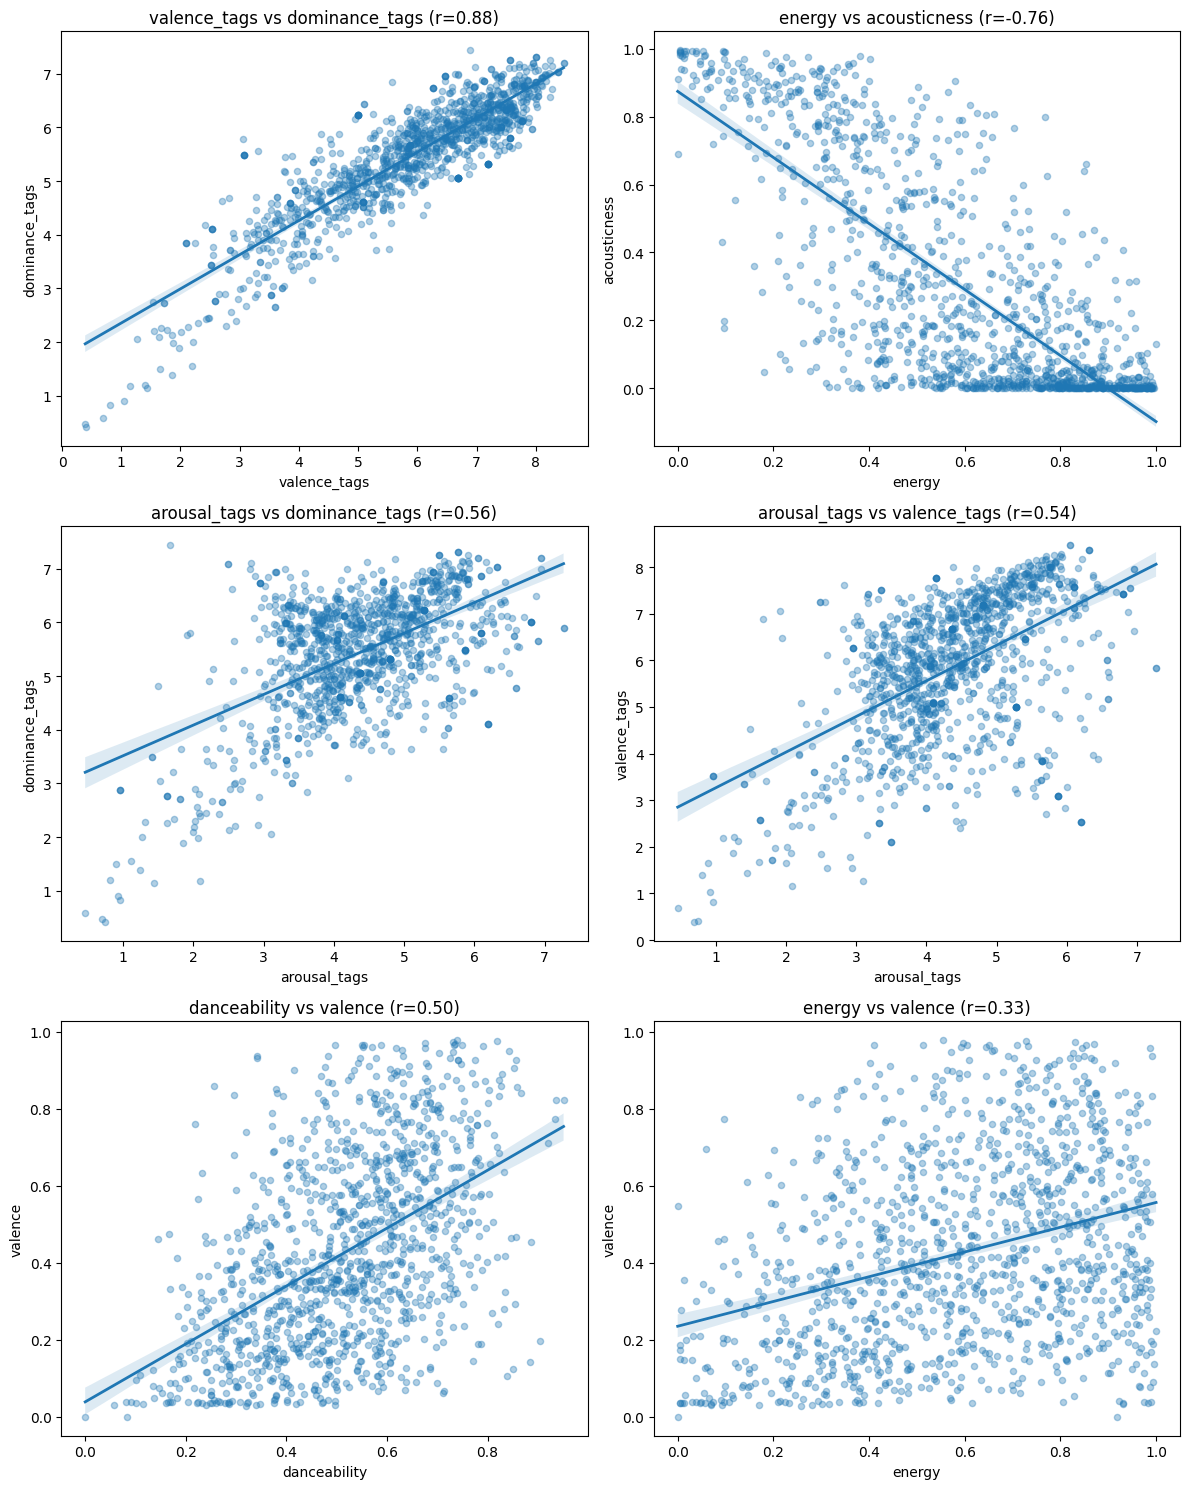

In [ ]:
# Full numeric correlation heatmap + focused scatter for strongest pairs.
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (All Numeric Features)')
plt.tight_layout()
plt.show()

# Only visualize pairs with stronger absolute correlation first.
plot_pairs = pair_corr[pair_corr['abs_corr'] >= 0.30].head(6).copy()
if plot_pairs.empty:
    plot_pairs = pair_corr.head(4).copy()

n_plots = len(plot_pairs)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, (_, row) in enumerate(plot_pairs.iterrows()):
    ax = axes[i]
    sns.regplot(
        data=df,
        x=row['feature_1'],
        y=row['feature_2'],
        scatter_kws={'alpha': 0.35, 's': 20},
        line_kws={'linewidth': 2},
        ax=ax
    )
    ax.set_title(f"{row['feature_1']} vs {row['feature_2']} (r={row['corr']:.2f})")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

6) outlier snapshot with boxplots

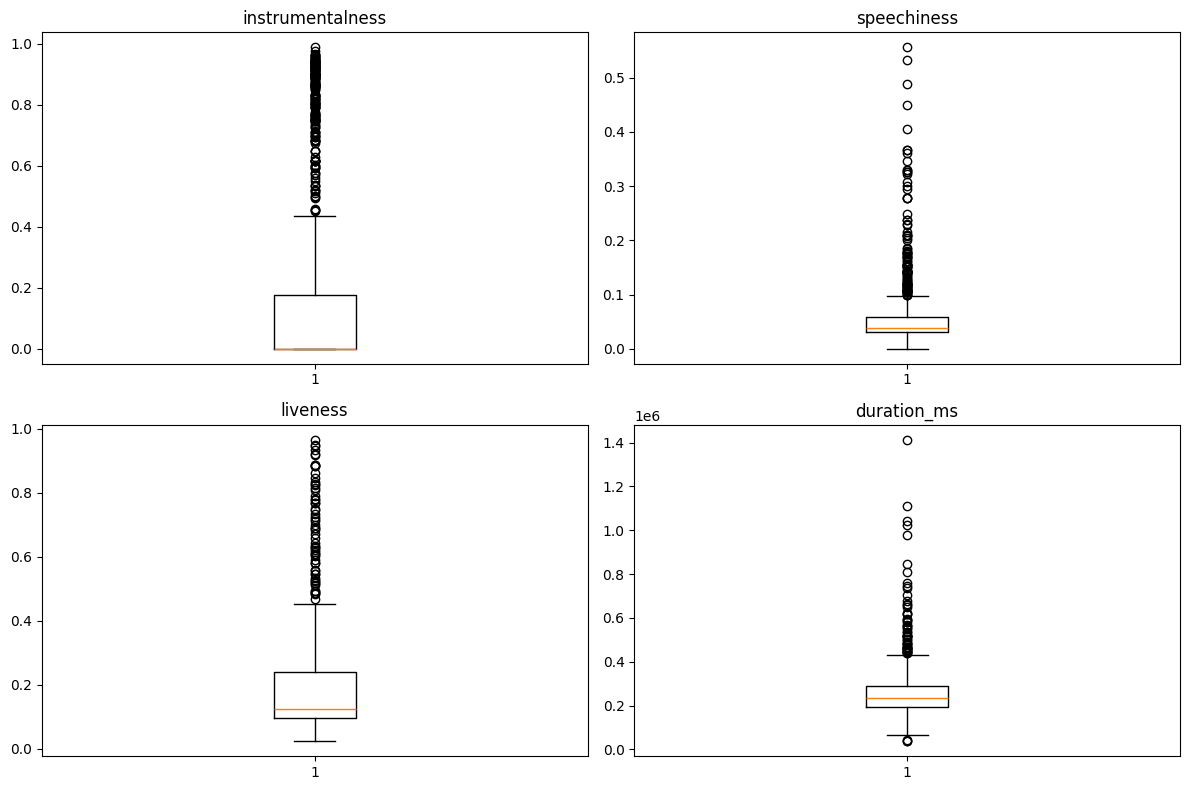

In [12]:
iqr_rows = []
for col in numeric_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = int(((s < lower) | (s > upper)).sum())
    iqr_rows.append({
        'feature': col,
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(s) * 100, 2)
    })

outlier_summary = pd.DataFrame(iqr_rows).sort_values('outlier_pct', ascending=False).reset_index(drop=True)
outlier_summary

outlier_plot_cols = outlier_summary[outlier_summary['outlier_pct'] > 0].head(4)['feature'].tolist()
if not outlier_plot_cols:
    outlier_plot_cols = outlier_summary.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_plot_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

7) frequency view of most common artists

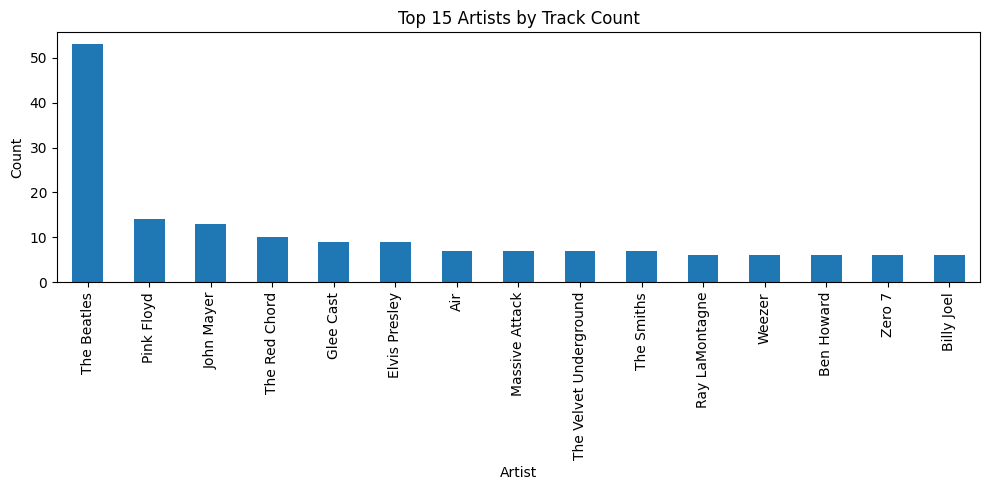

In [13]:
top_artists = df['artist'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_artists.plot(kind='bar')
plt.title('Top 15 Artists by Track Count')
plt.xlabel('Artist')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

emotional relationships

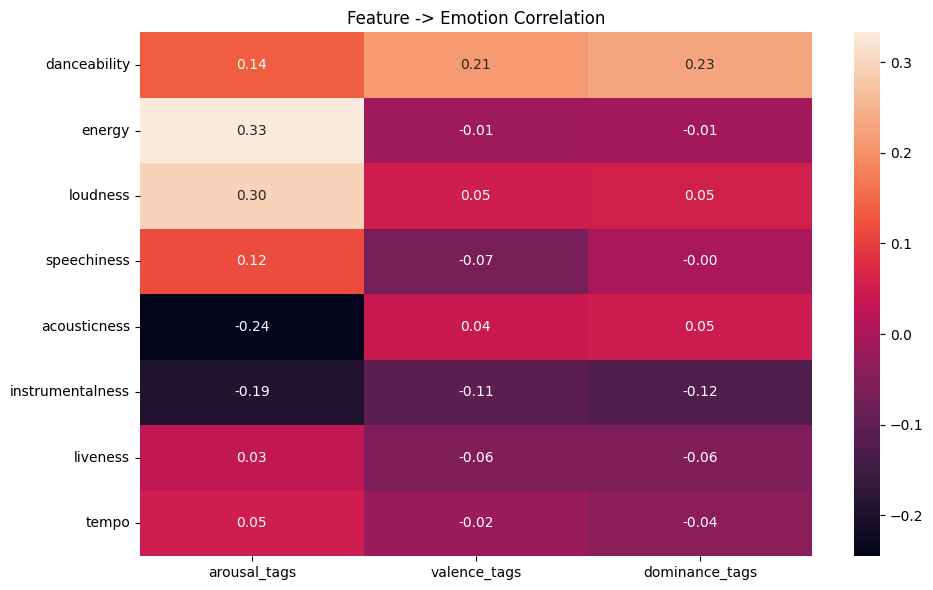

In [14]:
emotion_targets = ['arousal_tags', 'valence_tags', 'dominance_tags']

feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'tempo'
]

emotion_corr = df[feature_cols + emotion_targets].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(emotion_corr.loc[feature_cols, emotion_targets], annot=True, fmt='.2f')
plt.title('Feature -> Emotion Correlation')
plt.tight_layout()
plt.show()

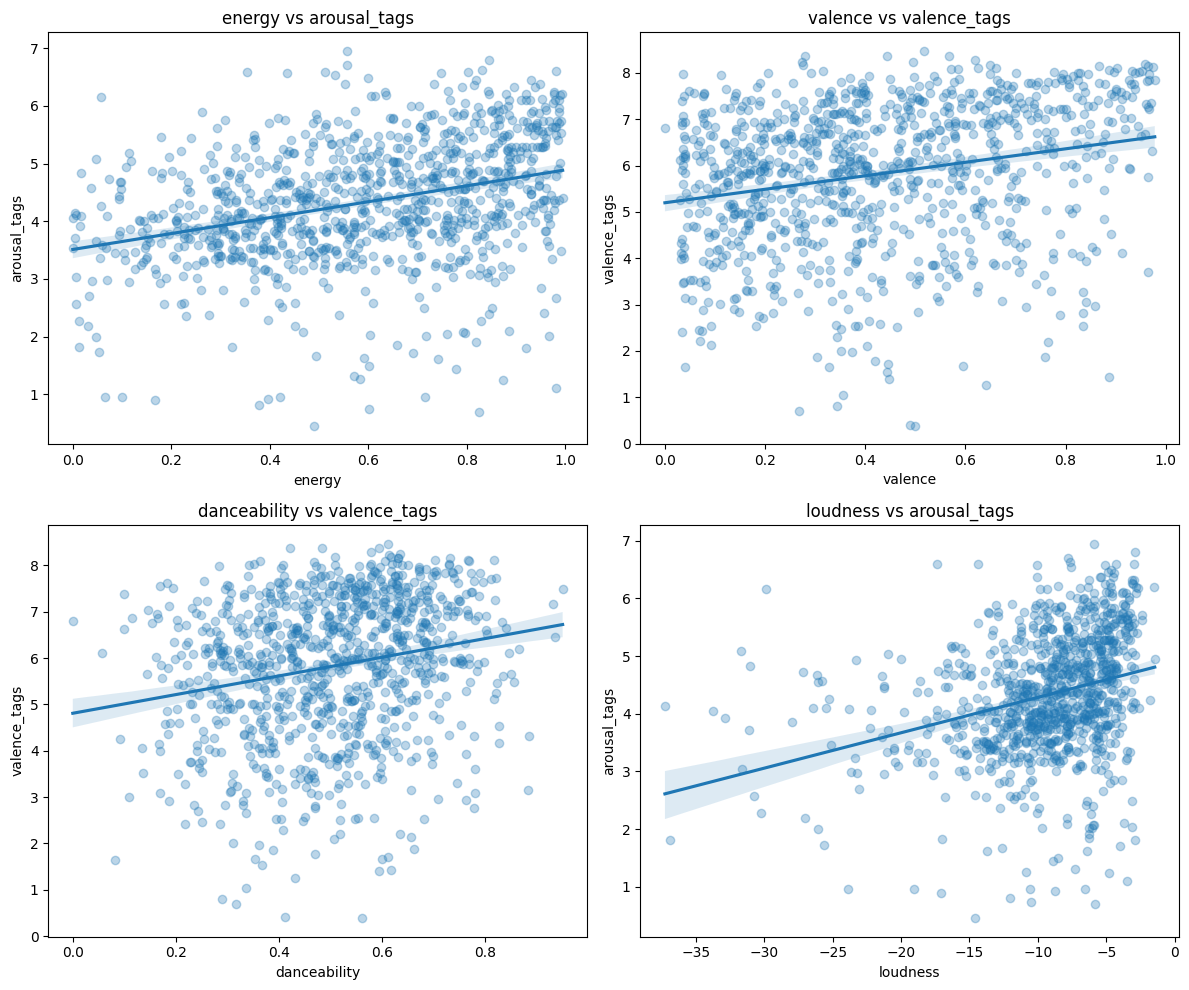

In [15]:
key_pairs = [
    ('energy', 'arousal_tags'),
    ('valence', 'valence_tags'),
    ('danceability', 'valence_tags'),
    ('loudness', 'arousal_tags')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(key_pairs):
    sns.regplot(data=df, x=x, y=y, ax=axes[i],
                scatter_kws={'alpha': 0.3})
    axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

# 5. Hypothesis Generation

plot correlations with popularity to determine what numeric features drive a track's success

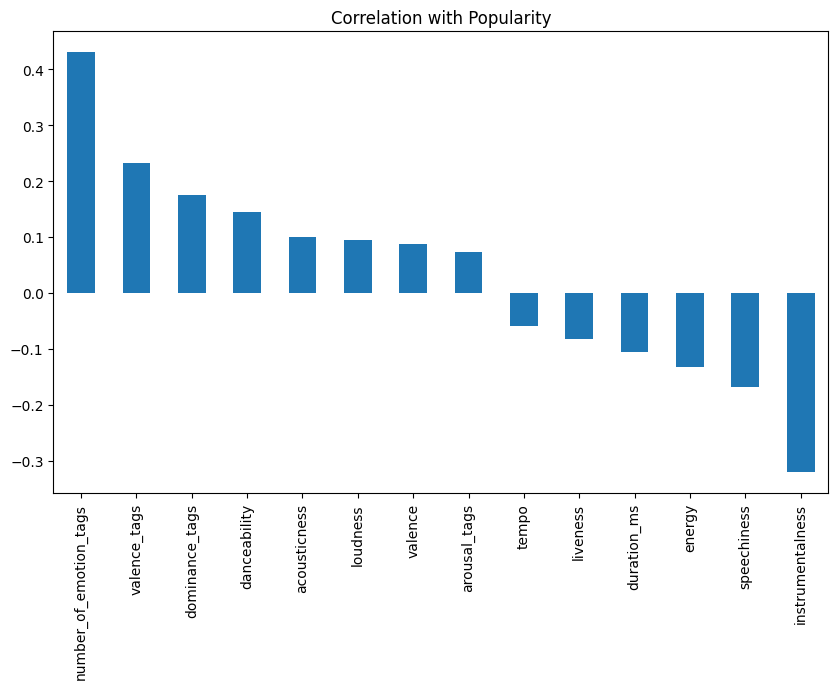

In [16]:
pop_corr = df[numeric_cols].corr()['popularity'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
pop_corr.drop('popularity').plot(kind='bar')
plt.title('Correlation with Popularity')
plt.show()

The cleaned dataset is moderately sized at 978 tracks, so trends are readable but still sensitive to artist/genre imbalance.
Emotion tag dimensions are tightly connected:
valence_tags and dominance_tags show a very strong positive correlation (r = 0.887), and both are moderately related to arousal_tags (r = 0.543 to 0.572).
Acoustic profile splits clearly along energy:
energy and acousticness are strongly inversely related (r = -0.760). High-energy tracks are generally less acoustic.
Musical positivity patterns are coherent:
danceability and valence correlate moderately (r = 0.534), and energy also rises with valence (r = 0.336).
The outlier plots confirm heavy right tails in a few features, not random noise:
instrumentalness (19.33% outliers), speechiness (11.04%), liveness (6.34%), and duration_ms (6.03%) are the main drivers.
The data is not evenly distributed across categories:
rock-like labels dominate top genre counts, and one artist (The Beatles, 53 tracks) appears far more often than most others. This can bias correlation strength and model fit toward dominant groups.


Build a robust version of the analysis:
rerun correlations with Spearman rank and compare to Pearson to reduce sensitivity to outliers.
Add genre-stratified EDA:
compute the same correlation matrix within top genres to test whether relationships are global or genre-specific.
Add artist-leakage controls:
repeat key analyses after limiting max tracks per artist (for example, cap at 5) and compare effect sizes.
Add transformed-feature visuals:
use log1p for duration_ms, speechiness, and instrumentalness before plotting histograms and boxplots.
Move from pairwise to partial effects:
fit multivariate models for arousal_tags, valence_tags, and dominance_tags with standardized coefficients.
Validate stability:
bootstrap correlations and report confidence intervals so findings are stated with uncertainty bounds.